<a href="https://colab.research.google.com/github/Sanjana-Munikrishnappa/ML_Saftey_Retrained/blob/ML-Saftey-Retrained/ML_Excercise__6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mount Google Drive

Mounts your Google Drive, allowing the notebook to access files stored there. This is necessary to load the dataset and pre-trained models.

In [ ]:
import google.colab.drive as gdrive

mount_path = "/content/drive"
gdrive.mount(mount_path)

Mounted at /content/drive


## Extract Test Dataset

Extracts the `test.zip` file, containing the test images and labels, into a local directory named `test`.

In [ ]:
import zipfile
from pathlib import Path

zip_path = Path("/content/drive/MyDrive/carla_dataset/test.zip")
extract_path = Path("test")

archive = zipfile.ZipFile(zip_path, mode="r")
archive.extractall(extract_path)
archive.close()

print("Done")

Done


## Import Libraries

Imports all the necessary libraries for data manipulation, visualization, and deep learning, including `numpy`, `pandas`, `matplotlib`, `torch`, `PIL`, and `torchvision.transforms`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset

from PIL import Image
import torchvision.transforms as T

## Load Test Labels

Loads the `labels.csv` file from the extracted test dataset into a pandas DataFrame called `labels_df_test` and displays its first few rows to inspect the data format.

In [ ]:
csv_file = "test/test/labels.csv"

labels_df_test = (
    pd.read_csv(csv_file)
      .copy()
)

labels_df_test.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,False,15,0,35
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249


## Define DrivingDataset Class

Defines a custom PyTorch `Dataset` class, `DrivingDataset`, which is responsible for loading images and their corresponding labels based on the provided DataFrame and image folder. This initial version may have issues with image path formatting (e.g., zero-padding for filenames), which will be addressed later.

In [ ]:
from pathlib import Path

class DrivingDataset(Dataset):

    def __init__(self, image_folder, labels_df, target_column, transform=None):
        self.image_dir = Path(image_folder)
        self.transform = transform

        self.frames = labels_df["frame"].tolist()
        self.labels = labels_df[target_column].astype(float).tolist()

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, index):
        img_path = self.image_dir / f"{self.frames[index]}.png"

        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        target = self.labels[index]

        return image, target

## Define Image Transformation for 64x64 Images

Defines an image transformation pipeline, `image_transform`, using `torchvision.transforms` to resize images to 64x64 pixels and convert them into PyTorch tensors. While defined, this specific transformation might not be actively used for the final model, which expects 224x224 images.

In [ ]:
image_transform = T.Compose(
    [
        T.Resize(size=(64, 64)),
        T.ToTensor(),
    ]
)

## Check GPU Availability and Set Device

Checks if a CUDA-enabled GPU is available and sets the `device` variable to either `cuda` (if available) or `cpu` for PyTorch operations.

In [ ]:
gpu_available = torch.cuda.is_available()
device = torch.device("cuda" if gpu_available else "cpu")

print(device)

cpu


## Define Traffic Light Classifier (64x64 input)

Defines the `TrafficLightClassifier` neural network architecture. This model is designed to accept 64x64 input images. Although defined, a different model architecture (`TrafficLightClassifier224`) for larger input images is used later in the notebook for actual inference.

In [ ]:
class TrafficLightClassifier(nn.Module):

    def __init__(self):
        super(TrafficLightClassifier, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Define Image Transformation for 224x224 Images

Defines an updated image transformation pipeline, `image_transform_224`, which resizes images to 224x224 pixels and converts them to PyTorch tensors. This transformation will be used for models trained on larger image inputs.

In [ ]:
image_transform_224 = T.Compose(
    (
        T.Resize(size=(224, 224)),
        T.ToTensor()
    )
)

## Define Traffic Light Classifier (224x224 input)

Defines the `TrafficLightClassifier224` neural network architecture, specifically designed to handle 224x224 input images. It then loads the pre-trained weights for the traffic light detection model, moves it to the appropriate device (CPU or GPU), and sets it to evaluation mode.

In [ ]:
class TrafficLightClassifier224(nn.Module):

    def __init__(self):
        super(TrafficLightClassifier224, self).__init__()

        layers = [
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(inplace=True),

            nn.Linear(128, 1)
        ]

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

## Load Pre-trained Traffic Light Model

Loads the pre-trained `traffic_light_model.pth` into the `TrafficLightClassifier224` model. It ensures the model is on the correct device (CPU/GPU) and sets it to evaluation mode for inference.

In [ ]:
model_path = "/content/drive/MyDrive/carla_dataset/traffic_light_model.pth"

traffic_light_model_224 = TrafficLightClassifier224()
weights = torch.load(model_path, map_location=device)

traffic_light_model_224.load_state_dict(weights)
traffic_light_model_224 = traffic_light_model_224.to(device)

traffic_light_model_224.eval()

print("Traffic Light model loaded")

Traffic Light model loaded


## Initialize Traffic Light Test Dataset (Potential Issue)

Attempts to create a `DrivingDataset` for traffic light detection using the original `labels_df_test` and `image_transform_224`. As noted later in the notebook, the initial `DrivingDataset` class may have issues with correctly formatting image filenames, which is addressed by `DrivingDataset224Fixed`.

In [ ]:
traffic_light_test_dataset = DrivingDataset(
    test_images,
    labels_df_test,
    target,
    image_transform_224
)

print(len(traffic_light_test_dataset))

3600


## Explore Test Data Directory Structure

Prints the current working directory and lists the contents of the `test` directory to understand the extracted dataset's structure.

In [ ]:
from pathlib import Path

current_directory = Path.cwd()
test_directory = Path("test")

print(current_directory)
print([item.name for item in test_directory.iterdir()])

/content
['test']


## Explore Subdirectories of Test Data

Lists the contents of the `test/test` directory, revealing various data files and subfolders, including `rgb-front` which contains the images.

In [ ]:
from pathlib import Path

print([item.name for item in Path("test/test").iterdir()])

['imu.feather', 'weather.feather', 'sim.log', 'actions.feather', '.hydra', 'carla.log', 'labels.feather', 'segmentation-front', 'labels.csv', 'rgb-front', 'gnss.feather', 'collisions.feather']


## List Image Files

Accesses the `rgb-front` subdirectory within the test data, lists all image files, and prints the total number of images as well as the first 10 filenames. This is part of debugging the image loading process.

In [ ]:
from pathlib import Path

image_directory = Path("test/test/rgb-front")
image_files = [file.name for file in image_directory.iterdir()]

print(f"Number of images: {len(image_files)}")
print("First 10 images:")
print(image_files[:10])

Number of images: 3600
First 10 images:
['009560.jpg', '033410.jpg', '010690.jpg', '027350.jpg', '006190.jpg', '001780.jpg', '016360.jpg', '034480.jpg', '017500.jpg', '033060.jpg']


## Extract 'frame' Column

Extracts the 'frame' column from the `labels_df_test` DataFrame, which contains the frame numbers corresponding to the image files. This is used to verify the frame naming convention.

In [ ]:
frame_column = labels_df_test.loc[:, "frame"]

print(frame_column.head(10))

0     0
1    10
2    20
3    30
4    40
5    50
6    60
7    70
8    80
9    90
Name: frame, dtype: int64


## Filter Image Files by Prefix (Debugging)

Filters the list of image files to find those starting with '000000'. This step likely helps in understanding and debugging the zero-padding logic for image filenames, as `PIL.Image.open` expects exact filenames.

In [ ]:
prefix = "000000"

matches = list(filter(lambda filename: filename.startswith(prefix), image_files))

print(matches[:20])

['000000.jpg']


## Display a Slice of Image Files (Debugging)

Prints a slice of the `image_files` list, further aiding in the debugging process for understanding image naming and availability.

In [ ]:
start_index = 0
end_index = 50

print(image_files[start_index:end_index])

['009560.jpg', '033410.jpg', '010690.jpg', '027350.jpg', '006190.jpg', '001780.jpg', '016360.jpg', '034480.jpg', '017500.jpg', '033060.jpg', '016250.jpg', '027440.jpg', '031870.jpg', '006940.jpg', '002090.jpg', '002390.jpg', '013800.jpg', '005660.jpg', '008830.jpg', '020480.jpg', '026330.jpg', '024200.jpg', '026510.jpg', '004360.jpg', '004520.jpg', '026180.jpg', '010870.jpg', '027220.jpg', '008930.jpg', '011780.jpg', '021450.jpg', '024080.jpg', '011250.jpg', '003670.jpg', '022420.jpg', '025540.jpg', '035370.jpg', '016560.jpg', '010090.jpg', '012630.jpg', '007840.jpg', '024020.jpg', '013990.jpg', '009940.jpg', '021060.jpg', '024640.jpg', '029710.jpg', '014430.jpg', '030020.jpg', '032360.jpg']


## Define Fixed DrivingDataset Class

Defines `DrivingDataset224Fixed`, an improved version of the `DrivingDataset` class. It specifically addresses potential issues with image filename formatting by ensuring that frame numbers are zero-padded to six digits (`f"{self.frames[index]:06d}.jpg"`) before constructing the image path. This fix is crucial for correctly loading images.

In [ ]:
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset

class DrivingDataset224Fixed(Dataset):

    def __init__(self, image_folder, labels_df, target_column, transform=None):
        self.image_dir = Path(image_folder)
        self.transform = transform

        self.frames = labels_df["frame"].astype(int).tolist()
        self.targets = labels_df[target_column].astype(float).tolist()

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, index):

        file_name = f"{self.frames[index]:06d}.jpg"
        image = Image.open(self.image_dir / file_name).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        target = self.targets[index]

        return image, target

## Initialize Fixed Traffic Light Test Dataset

Creates the `traffic_light_test_dataset_fixed` using the corrected `DrivingDataset224Fixed` class. This dataset correctly loads images for the traffic light classification task and will be used for subsequent model evaluations.

In [ ]:
traffic_light_test_dataset_fixed = DrivingDataset224Fixed(
    image_folder="test/test/rgb-front",
    labels_df=labels_df_test,
    target_column="has_traffic_light",
    transform=image_transform_224
)

print(len(traffic_light_test_dataset_fixed))

3600


## Generate Saliency Map for a Correctly Classified Traffic Light Image

Selects a sample image from the fixed traffic light dataset, feeds it through the traffic light model, and generates a saliency map. The `prediction.backward()` call computes gradients, which are then used to visualize which parts of the image the model focused on for its classification.

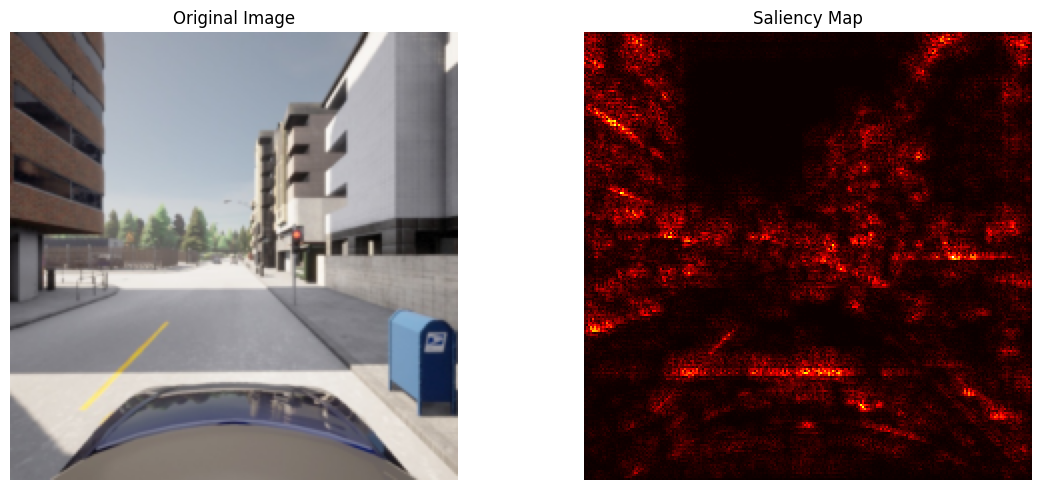

In [ ]:
image, label = traffic_light_test_dataset_fixed.__getitem__(1)

input_image = image.unsqueeze(dim=0).to(device)
input_image.requires_grad = True

prediction = traffic_light_model_224(input_image)
prediction.backward()

saliency_map = torch.amax(input_image.grad.abs(), dim=1)

figure, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image.permute(1, 2, 0))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(saliency_map.squeeze().cpu().numpy(), cmap="hot")
axes[1].set_title("Saliency Map")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Display Saliency Map for a Correctly Classified Traffic Light Image

Visualizes the original image and its corresponding saliency map for the selected sample. The saliency map highlights the pixels that most influenced the model's prediction, helping to interpret its decision-making process.

In [ ]:
correct_indices = []

dataset_length = len(traffic_light_test_dataset_fixed)

for index in range(dataset_length):

    sample_image, sample_label = traffic_light_test_dataset_fixed.__getitem__(index)

    model_input = sample_image.unsqueeze(0).to(device)

    with torch.inference_mode():
        probability = torch.sigmoid(
            traffic_light_model_224(model_input)
        ).item()

    predicted_label = int(probability > 0.5)

    if predicted_label == int(sample_label):
        correct_indices.append(index)

        if len(correct_indices) >= 5:
            break

print(correct_indices)

[0, 1, 2, 3, 4]


## Visualize Saliency Maps for Correctly Classified Traffic Light Samples

Loops through the `sample_indices` (correctly classified samples) and generates/displays the original image and its saliency map for each. This helps to understand why the model made correct predictions by showing the areas it focused on.

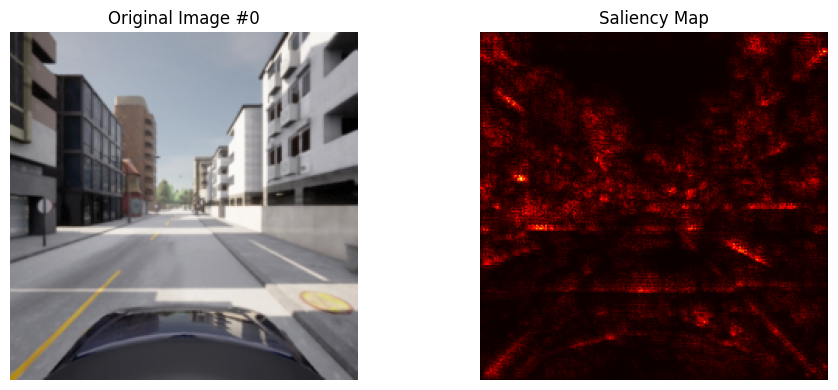

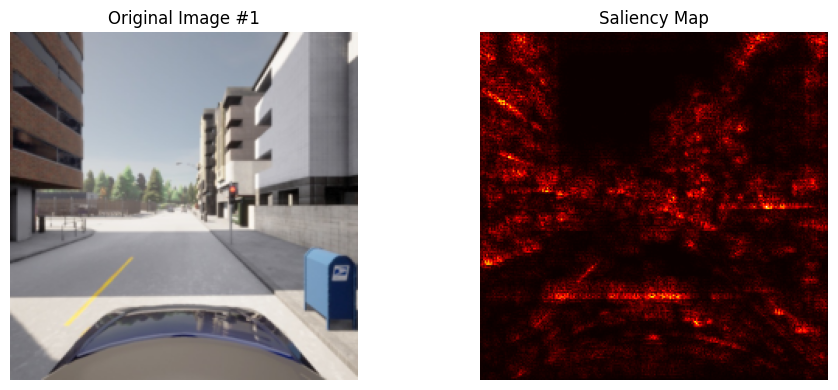

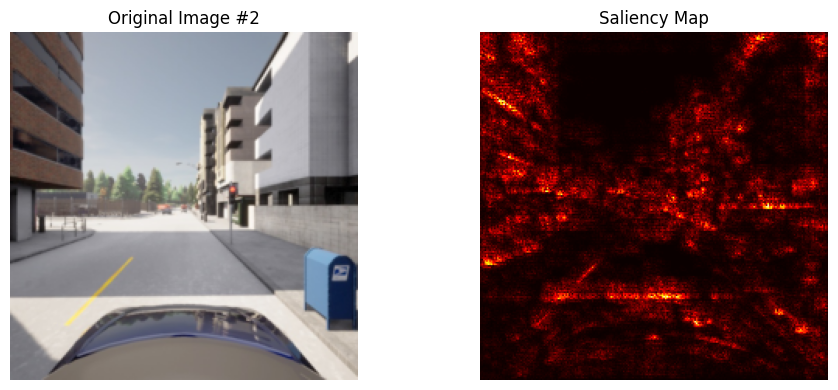

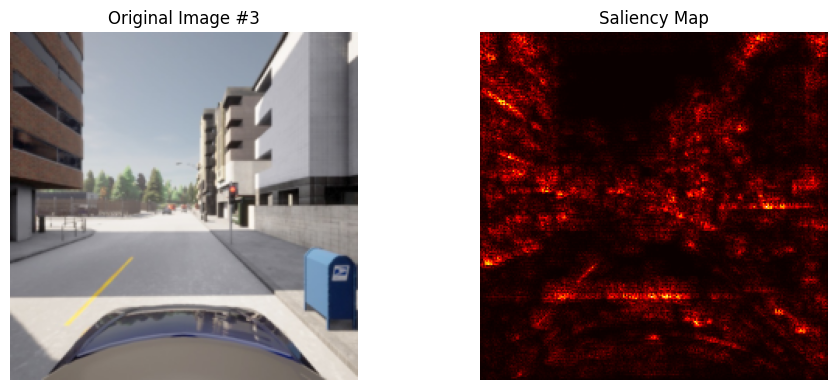

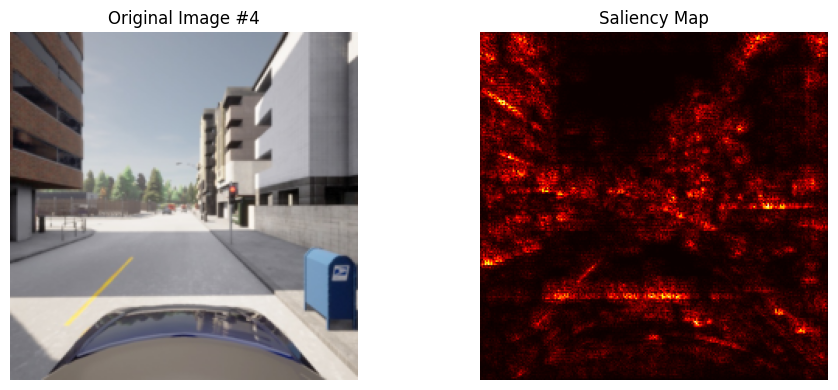

In [ ]:
sample_indices = range(5)

for index in sample_indices:

    image, label = traffic_light_test_dataset_fixed.__getitem__(index)

    model_input = image.unsqueeze(0).to(device)
    model_input.requires_grad = True

    traffic_light_model_224.zero_grad(set_to_none=True)

    prediction = traffic_light_model_224(model_input)
    prediction.backward()

    saliency_map = torch.amax(model_input.grad.abs(), dim=1)

    figure, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(image.permute(1, 2, 0))
    axes[0].set_title(f"Original Image #{index}")
    axes[0].axis("off")

    axes[1].imshow(saliency_map.squeeze().cpu().numpy(), cmap="hot")
    axes[1].set_title("Saliency Map")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

## List All Pre-trained Model Files

Searches the specified Google Drive folder for all `.pth` files (PyTorch model state dictionaries) and prints their filenames. This helps in identifying available pre-trained models.

In [ ]:
from pathlib import Path

model_directory = Path("/content/drive/MyDrive/carla_dataset")

for model_file in model_directory.rglob("*.pth"):
    print(model_file.name)

traffic_light_model.pth
pedestrian_model.pth
vehicle_model.pth


## Display DataFrame Column Names

Prints all column names present in the `labels_df_test` DataFrame, which is useful for verifying available target columns for classification tasks.

In [ ]:
column_names = labels_df_test.columns

print(column_names)

Index(['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle',
       'px_traffic_light', 'px_pedestrian', 'px_vehicle'],
      dtype='object')


## Define and Load Pedestrian Classifier Model

Defines the `PedestrianClassifier224` neural network architecture, similar to the traffic light classifier but for pedestrian detection. It then loads the pre-trained weights for the pedestrian model, moves it to the appropriate device, and sets it to evaluation mode.

In [ ]:
class PedestrianClassifier224(nn.Module):

    def __init__(self):
        super(PedestrianClassifier224, self).__init__()

        layers = [
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Flatten(),

            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(inplace=True),

            nn.Linear(128, 1)
        ]

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


model_path = "/content/drive/MyDrive/carla_dataset/pedestrian_model.pth"

pedestrian_model_224 = PedestrianClassifier224()
state_dict = torch.load(model_path, map_location=device)

pedestrian_model_224.load_state_dict(state_dict)
pedestrian_model_224 = pedestrian_model_224.to(device)

pedestrian_model_224.eval()

print("Pedestrian model loaded")

Pedestrian model loaded


## Find Correctly Classified Samples for Pedestrian Model

Initializes a dataset for pedestrian detection using `DrivingDataset224Fixed` and then iterates through it to find the first 5 images that the pedestrian model classifies correctly. These indices are stored for further analysis, such as saliency map visualization.

In [ ]:
pedestrian_test_dataset_fixed = DrivingDataset224Fixed(
    image_folder="test/test/rgb-front",
    labels_df=labels_df_test,
    target_column="has_pedestrian",
transform=image_transform_224)

correct_indices = []

total_samples = len(pedestrian_test_dataset_fixed)

for index in range(total_samples):

    sample_image, sample_label = pedestrian_test_dataset_fixed.__getitem__(index)

    model_input = sample_image.unsqueeze(0).to(device)

    with torch.inference_mode():
        probability = torch.sigmoid(
            pedestrian_model_224(model_input)
        ).item()

    predicted_label = int(probability > 0.5)

    if predicted_label == int(sample_label):
        correct_indices.append(index)

        if len(correct_indices) >= 5:
            break

print(correct_indices)

[0, 1, 2, 3, 4]


## Generate and Display Saliency Map for a Correctly Classified Pedestrian Image

Takes one of the correctly classified pedestrian samples, generates its saliency map, and displays both the original image and the saliency map. This helps to understand which features the pedestrian model relies on for its predictions.

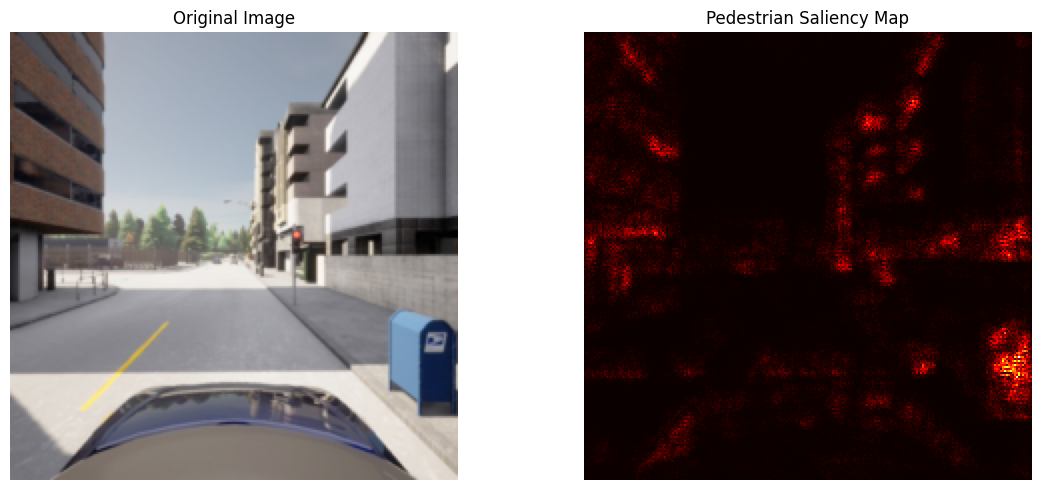

In [ ]:
image, label = pedestrian_test_dataset_fixed.__getitem__(1)

input_image = image.unsqueeze(0).to(device)
input_image.requires_grad = True

pedestrian_model_224.zero_grad(set_to_none=True)

prediction = pedestrian_model_224(input_image)
prediction.backward()

saliency = torch.amax(input_image.grad.abs(), dim=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image.permute(1, 2, 0))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(saliency.squeeze().cpu().numpy(), cmap="hot")
axes[1].set_title("Pedestrian Saliency Map")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Define and Load Vehicle Classifier Model

Defines the `VehicleClassifier224` neural network architecture for vehicle detection. It then loads the pre-trained weights for the vehicle model, moves it to the appropriate device, and sets it to evaluation mode.

In [ ]:
class VehicleClassifier224(nn.Module):

    def __init__(self):
        super(VehicleClassifier224, self).__init__()

        network_layers = [
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Flatten(),

            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(inplace=True),

            nn.Linear(128, 1)
        ]

        self.model = nn.Sequential(*network_layers)

    def forward(self, x):
        return self.model(x)


model_path = "/content/drive/MyDrive/carla_dataset/vehicle_model.pth"

vehicle_model_224 = VehicleClassifier224()
state_dict = torch.load(model_path, map_location=device)

vehicle_model_224.load_state_dict(state_dict)
vehicle_model_224 = vehicle_model_224.to(device)

vehicle_model_224.eval()

print("Vehicle model loaded")

Vehicle model loaded


## Find Correctly Classified Samples for Vehicle Model

Initializes a dataset for vehicle detection using `DrivingDataset224Fixed` and iterates through it to find the first 5 images that the vehicle model classifies correctly. These indices are stored for subsequent visualization.

In [ ]:
transform_224 = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

vehicle_test_dataset_fixed = DrivingDataset224Fixed(
    image_folder="test/test/rgb-front",
    labels_df=labels_df_test,
    target_column="has_vehicle",
    transform=transform_224
)

correct_indices = []

dataset_size = len(vehicle_test_dataset_fixed)

for index in range(dataset_size):

    sample_image, sample_label = vehicle_test_dataset_fixed.__getitem__(index)

    model_input = sample_image.unsqueeze(0).to(device)

    with torch.inference_mode():
        probability = torch.sigmoid(
            vehicle_model_224(model_input)
        ).item()

    predicted_label = int(probability > 0.5)

    if predicted_label == int(sample_label):
        correct_indices.append(index)

        if len(correct_indices) >= 5:
            break

print(correct_indices)

[1, 2, 3, 4, 5]


## Generate and Display Saliency Map for a Correctly Classified Vehicle Image

Takes one of the correctly classified vehicle samples, generates its saliency map, and displays both the original image and the saliency map. This visualization helps in understanding the vehicle model's focus points.

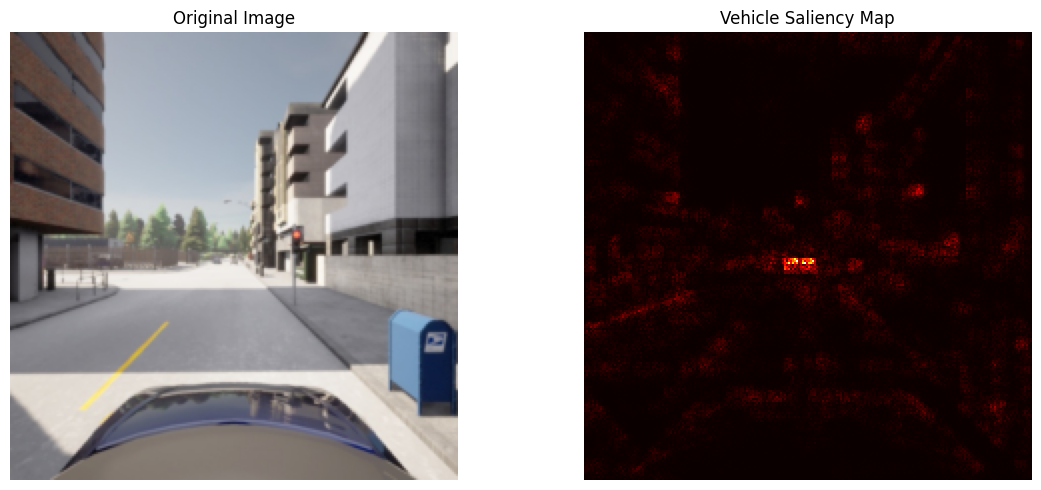

In [ ]:
image, label = vehicle_test_dataset_fixed.__getitem__(1)

input_image = image.unsqueeze(0).to(device)
input_image.requires_grad = True

vehicle_model_224.zero_grad(set_to_none=True)

prediction = vehicle_model_224(input_image)
prediction.backward()

saliency = torch.amax(input_image.grad.abs(), dim=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image.permute(1, 2, 0))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(saliency.squeeze().cpu().numpy(), cmap="hot")
axes[1].set_title("Vehicle Saliency Map")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Find Misclassified Samples for Traffic Light Model

Iterates through the `traffic_light_test_dataset_fixed` to identify and store the indices of the first 3 images that the traffic light model *misclassifies*. These samples are important for understanding the model's limitations and failure cases.

## Visualize Saliency Maps for Misclassified Traffic Light Samples

Loops through the `wrong_indices` (misclassified samples) and generates/displays the original image and its saliency map for each. This helps to analyze why the model made incorrect predictions by showing where its attention was directed.

In [ ]:
wrong_indices = []

total_samples = len(traffic_light_test_dataset_fixed)

for index in range(total_samples):

    sample_image, sample_label = traffic_light_test_dataset_fixed.__getitem__(index)

    model_input = sample_image.unsqueeze(0).to(device)

    with torch.inference_mode():
        probability = torch.sigmoid(
            traffic_light_model_224(model_input)
        ).item()

    predicted_label = int(probability > 0.5)

    if predicted_label != int(sample_label):
        wrong_indices.append(index)

        if len(wrong_indices) >= 3:
            break

print(wrong_indices)

[13, 16, 120]


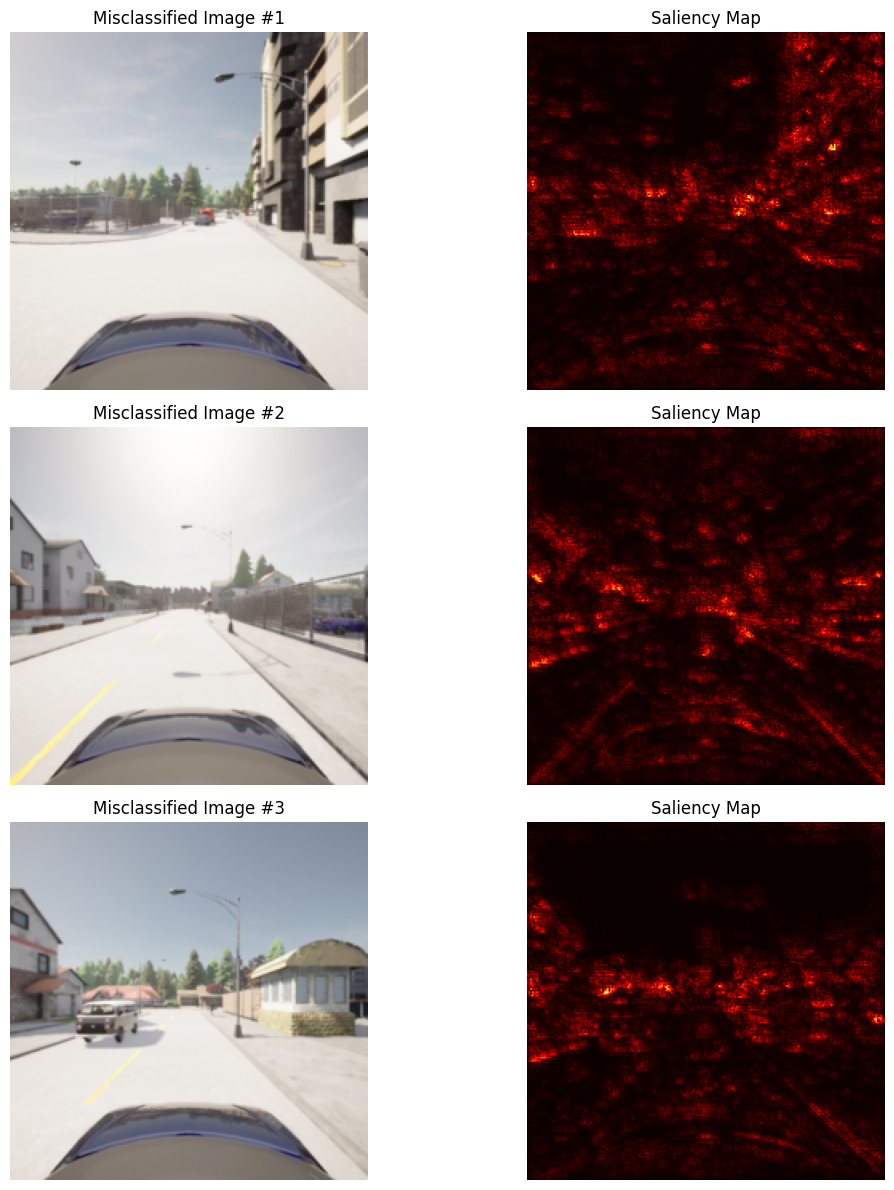

In [ ]:
figure, axes = plt.subplots(3, 2, figsize=(12, 12))

for plot_idx, sample_index in enumerate(wrong_indices):

    image, label = traffic_light_test_dataset_fixed.__getitem__(sample_index)

    input_image = image.unsqueeze(0).to(device)
    input_image.requires_grad = True

    traffic_light_model_224.zero_grad(set_to_none=True)

    prediction = traffic_light_model_224(input_image)
    prediction.backward()

    saliency = torch.amax(input_image.grad.abs(), dim=1)

    axes[plot_idx, 0].imshow(image.permute(1, 2, 0))
    axes[plot_idx, 0].set_title(f"Misclassified Image #{plot_idx + 1}")
    axes[plot_idx, 0].axis("off")

    axes[plot_idx, 1].imshow(
        saliency.squeeze().cpu().numpy(),
        cmap="hot"
    )
    axes[plot_idx, 1].set_title("Saliency Map")
    axes[plot_idx, 1].axis("off")

plt.tight_layout()
plt.show()

## List Contents of Carla Dataset Drive Folder

Lists the contents of the `/content/drive/MyDrive/carla_dataset` folder. This helps to verify the presence of various zip files and model weights needed for the project.

In [ ]:
from pathlib import Path

drive_folder = Path("/content/drive/MyDrive/carla_dataset")

print([item.name for item in drive_folder.iterdir()])

['test.zip', 'train.zip', 'validation.zip', 'train', 'test', 'validation', 'test-fog.zip', 'test-night.zip', 'test-town-01.zip', 'traffic_light_model.pth', 'pedestrian_model.pth', 'vehicle_model.pth']


## Extract Fog and Night Datasets

Extracts the `test-fog.zip` and `test-night.zip` archives, which contain additional test datasets under different weather and lighting conditions. These are extracted to `/content/test-fog` and `/content/test-night` respectively.

In [ ]:
from zipfile import ZipFile

zip_files = {
    "/content/drive/MyDrive/carla_dataset/test-fog.zip": "/content/test-fog",
    "/content/drive/MyDrive/carla_dataset/test-night.zip": "/content/test-night"
}

for zip_path, extract_path in zip_files.items():
    with ZipFile(zip_path, "r") as archive:
        archive.extractall(extract_path)

print("Extraction completed.")

Extraction completed.


## Verify Extraction of Fog and Night Data

Checks the contents of the newly created `/content/test-fog` and `/content/test-night` directories to ensure the datasets were extracted successfully.

In [ ]:
from pathlib import Path

fog_directory = Path("/content/test-fog")
night_directory = Path("/content/test-night")

print("FOG:")
print([item.name for item in fog_directory.iterdir()])

print("\nNIGHT:")
print([item.name for item in night_directory.iterdir()])

FOG:
['test-fog']

NIGHT:
['test-night']


## Explore Fog Dataset Structure

Lists the contents of the `/content/test-fog/test-fog` directory, confirming the presence of various data files and the `rgb-front` folder containing images under fog conditions.

In [ ]:
from pathlib import Path

fog_path = Path("/content/test-fog/test-fog")

print([item.name for item in fog_path.iterdir()])

['imu.feather', 'weather.feather', 'sim.log', 'actions.feather', '.hydra', 'carla.log', 'labels.feather', 'segmentation-front', 'labels.csv', 'rgb-front', 'gnss.feather', 'collisions.feather']


## Explore Night Dataset Structure

Lists the contents of the `/content/test-night/test-night` directory, confirming the presence of various data files and the `rgb-front` folder containing images under night conditions.

In [ ]:
from pathlib import Path

night_folder = Path("/content/test-night/test-night")

print([item.name for item in night_folder.iterdir()])

['imu.feather', 'weather.feather', 'sim.log', 'actions.feather', '.hydra', 'carla.log', 'labels.feather', 'segmentation-front', 'labels.csv', 'rgb-front', 'gnss.feather', 'collisions.feather']


## Load Fog Labels and Initialize Fog Dataset

Loads the `labels.csv` file for the fog dataset into `labels_df_fog` and then initializes `fog_dataset` using the `DrivingDataset224Fixed` class for traffic light detection under fog conditions.

In [ ]:
csv_path = "/content/test-fog/test-fog/labels.csv"

labels_df_fog = (
    pd.read_csv(csv_path)
      .copy()
)

print(labels_df_fog.head())
print(labels_df_fog.shape[0])

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False        False                15   
1     10               True           False         True               299   
2     20               True           False         True               298   
3     30               True           False         True               297   
4     40               True           False         True               297   

   px_pedestrian  px_vehicle  
0              0          35  
1              0         116  
2              0         307  
3              0         258  
4              0         249  
3600


## Create Fog Dataset Instance

Constructs an instance of `DrivingDataset224Fixed` for the fog images, targeting 'has_traffic_light' labels. It then prints the length of the created dataset.

In [ ]:
dataset_options = {
    "image_folder": "/content/test-fog/test-fog/rgb-front",
    "labels_df": labels_df_fog,
    "target_column": "has_traffic_light",
    "transform": transform_224
}

fog_dataset = DrivingDataset224Fixed(**dataset_options)

dataset_length = len(fog_dataset)
print(dataset_length)

3600


## Generate Saliency Map Data for a Fog Image

Selects a sample image from the `fog_dataset`, feeds it through the traffic light model, and computes the saliency map. This process is crucial for understanding how the model perceives images under fog.

In [ ]:
sample_index = 0

image, label = fog_dataset.__getitem__(sample_index)

input_image = image.unsqueeze(0).to(device)
input_image.requires_grad = True

traffic_light_model_224.zero_grad(set_to_none=True)

prediction = traffic_light_model_224(input_image)
prediction.backward()

saliency = torch.amax(input_image.grad.abs(), dim=1)

## Display Saliency Map for a Fog Image

Visualizes the original fog image and its corresponding saliency map. This helps to see which parts of the image the traffic light model focuses on when making predictions in foggy conditions.

## Find Correctly Classified Samples for Traffic Light Model

This cell iterates through the `traffic_light_test_dataset_fixed` to identify and store the indices of the first 5 images that the traffic light model classifies correctly. This is done to find good examples for saliency map visualization.

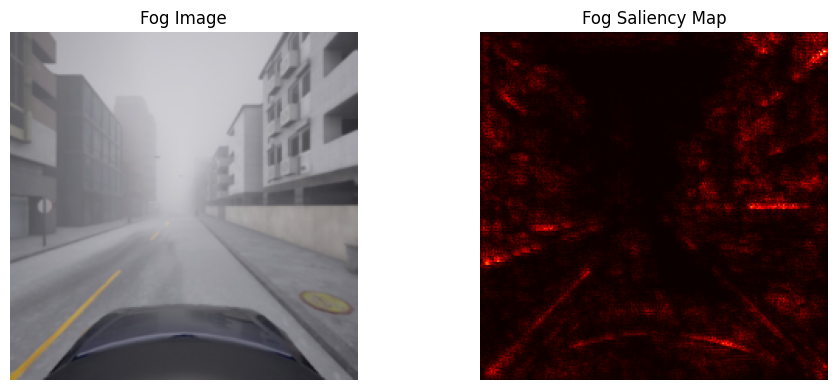

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(image.permute(1, 2, 0))
axes[0].set_title("Fog Image")
axes[0].axis("off")

axes[1].imshow(
    saliency.squeeze().cpu().numpy(),
    cmap="hot"
)
axes[1].set_title("Fog Saliency Map")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Load Night Labels and Initialize Night Dataset

Loads the `labels.csv` file for the night dataset into `labels_df_night` and then initializes `night_dataset` using the `DrivingDataset224Fixed` class for traffic light detection under night conditions.

In [ ]:
labels_path = "/content/test-night/test-night/labels.csv"

labels_df_night = (
    pd.read_csv(labels_path)
      .copy()
)

dataset_config = {
    "image_folder": "/content/test-night/test-night/rgb-front",
    "labels_df": labels_df_night,
    "target_column": "has_traffic_light",
    "transform": transform_224
}

night_dataset = DrivingDataset224Fixed(**dataset_config)

## Generate Saliency Map Data for a Night Image

Selects a sample image from the `night_dataset`, feeds it through the traffic light model, and computes the saliency map. This helps to analyze how the model behaves under low-light conditions.

In [ ]:
sample_index = 0

image, label = night_dataset.__getitem__(sample_index)

input_image = image.unsqueeze(0).to(device)
input_image.requires_grad = True

traffic_light_model_224.zero_grad(set_to_none=True)

prediction = traffic_light_model_224(input_image)
prediction.backward()

saliency = torch.amax(input_image.grad.abs(), dim=1)

## Display Saliency Map for a Night Image

Visualizes the original night image and its corresponding saliency map. This provides insight into where the traffic light model focuses its attention when predicting in night scenes.

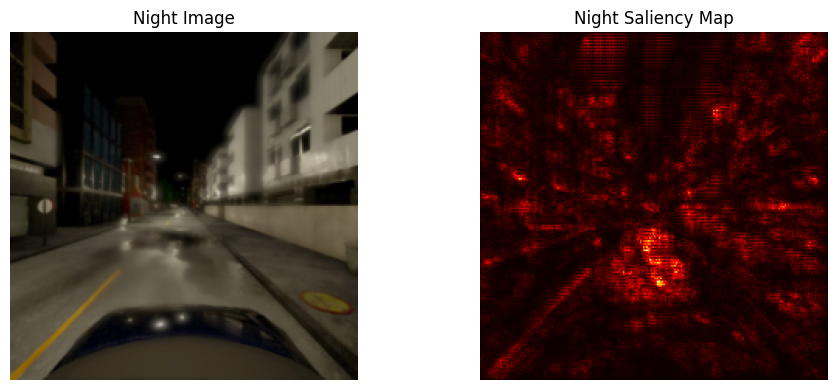

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(image.permute(1, 2, 0))
axes[0].set_title("Night Image")
axes[0].axis("off")

axes[1].imshow(
    saliency.squeeze().cpu().numpy(),
    cmap="hot"
)
axes[1].set_title("Night Saliency Map")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Extract Town Layout Dataset

Extracts the `test-town-01.zip` archive, which contains a test dataset captured in a specific town layout. It is extracted to `/content/test-town`.

In [ ]:
from zipfile import ZipFile

zip_path = "/content/drive/MyDrive/carla_dataset/test-town-01.zip"
extract_path = "/content/test-town"

with ZipFile(zip_path, "r") as archive:
    archive.extractall(extract_path)

print("Extraction completed.")

Extraction completed.


## Verify Extraction of Town Data

Checks the contents of the newly created `/content/test-town` directory to ensure the town layout dataset was extracted successfully.

In [ ]:
from pathlib import Path

town_directory = Path("/content/test-town")

print([item.name for item in town_directory.iterdir()])

['test-town-01']


## Explore Town Layout Dataset Structure

Lists the contents of the `/content/test-town/test-town-01` directory, confirming the presence of various data files and the `rgb-front` folder containing images specific to the town layout.

In [ ]:
from pathlib import Path

town_folder = Path("/content/test-town/test-town-01")

print([item.name for item in town_folder.iterdir()])

['imu.feather', 'weather.feather', 'sim.log', 'actions.feather', '.hydra', 'carla.log', 'labels.feather', 'segmentation-front', 'labels.csv', 'rgb-front', 'gnss.feather', 'collisions.feather']


## Load Town Labels and Initialize Town Dataset

Loads the `labels.csv` file for the town layout dataset into `labels_df_town` and then initializes `town_dataset` using the `DrivingDataset224Fixed` class for traffic light detection in this environment.

In [ ]:
labels_file = "/content/test-town/test-town-01/labels.csv"

labels_df_town = pd.read_csv(labels_file).copy()

dataset_params = {
    "image_folder": "/content/test-town/test-town-01/rgb-front",
    "labels_df": labels_df_town,
    "target_column": "has_traffic_light",
    "transform": transform_224
}

town_dataset = DrivingDataset224Fixed(**dataset_params)

## Generate Saliency Map Data for a Town Layout Image

Selects a sample image from the `town_dataset`, feeds it through the traffic light model, and computes the saliency map. This helps to understand how the model performs in this specific town environment.

In [ ]:
sample_index = 0

image, label = town_dataset.__getitem__(sample_index)

input_image = image.unsqueeze(0).to(device)
input_image.requires_grad = True

traffic_light_model_224.zero_grad(set_to_none=True)

prediction = traffic_light_model_224(input_image)
prediction.backward()

saliency = torch.amax(input_image.grad.abs(), dim=1)

## Display Saliency Map for a Town Layout Image

Visualizes the original town layout image and its corresponding saliency map, providing insight into the traffic light model's focus within this particular scene.

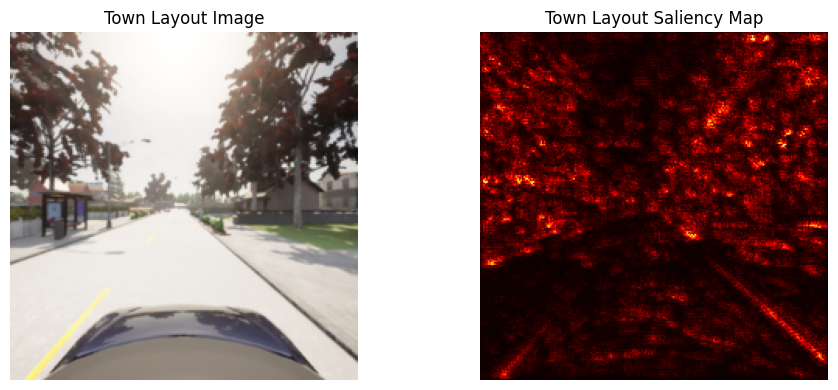

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

axes[0].imshow(image.permute(1, 2, 0))
axes[0].set_title("Town Layout Image")
axes[0].set_axis_off()

axes[1].imshow(
    saliency.squeeze().cpu().numpy(),
    cmap="hot"
)
axes[1].set_title("Town Layout Saliency Map")
axes[1].set_axis_off()

fig.tight_layout()
plt.show()

## Define Accuracy Evaluation Function

Defines the `evaluate_accuracy` function, which takes a model, dataset, and device as input. It iterates through the dataset, performs inference, calculates predictions, and returns the overall accuracy of the model on the given dataset.

In [ ]:
def evaluate_accuracy(model, dataset, device):

    model.eval()

    correct = 0
    total = len(dataset)

    with torch.inference_mode():

        for image, label in dataset:

            image = image.unsqueeze(0).to(device)

            output = model(image)

            probability = torch.sigmoid(output).item()

            prediction = int(probability > 0.5)

            if prediction == int(label):
                correct += 1

    accuracy = (correct / total) * 100

    return accuracy

## Evaluate Traffic Light Model Accuracy on Different Datasets

Uses the `evaluate_accuracy` function to calculate and print the accuracy of the `traffic_light_model_224` on the `fog_dataset`, `night_dataset`, and `town_dataset`. This provides a comparative analysis of the model's performance under various conditions.

In [ ]:
fog_accuracy = evaluate_accuracy(
    traffic_light_model_224,
    fog_dataset,
    device
)

night_accuracy = evaluate_accuracy(
    traffic_light_model_224,
    night_dataset,
    device
)

town_accuracy = evaluate_accuracy(
    traffic_light_model_224,
    town_dataset,
    device
)

print(f"Fog Accuracy   : {fog_accuracy:.2f}%")
print(f"Night Accuracy : {night_accuracy:.2f}%")
print(f"Town Accuracy  : {town_accuracy:.2f}%")

Fog Accuracy   : 76.72%
Night Accuracy : 27.53%
Town Accuracy  : 70.56%
